# 52 — Same question, with circles

Notebook 50 used bees. A bee's middle hints at the whole bee, and there were
only a few, so a network can cheat. Circles cannot be cheated.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from matplotlib.patches import Rectangle
from skimage.measure import regionprops
from tnia.plotting.plt_helper import imshow_multi2d, mask_outline_overlay

import circles
from skop.runner import Runner
from skop.ops.segment.stardist2d import stardist2d_custom
from skop.ops.train import extent, receptive_field_stardist2d, train_stardist2d

runner = Runner()

RADII = [3, 5, 15, 30, 60, 70]
test_img, test_lbl = circles.calibration(RADII)

DIAMETERS = [2 * r for r in RADII]
print('test image', test_img.shape, 'diameters', DIAMETERS)

test image (256, 534) diameters [6, 10, 30, 60, 120, 140]


In [5]:
# scikit-ops is in heavy development, so for now it is worth "ensuring" the
# environment each time -- check it is up to date, rebuild it if not.
runner.ensure_environment('stardist-tf')

stardist-tf: up to date


<appose.builder.BaseBuilder._create_env.<locals>.BuiltEnvironment at 0x7444a44078c0>

## Measure the receptive field

Send one bright pixel through the network. How far the response spreads is
what the network can see. Training does not change this. The shape does.

In [6]:
# Barely any depth, so a very small field on purpose.
SMALL_GRID, SMALL_DEPTH = 1, 1
BIG_GRID, BIG_DEPTH = 1, 4

small_net_field = min(extent(runner.run(
    receptive_field_stardist2d,
    grid_size_xy=SMALL_GRID,
    unet_n_depth=SMALL_DEPTH,
    n_channel_in=1,
    img_size=512,
)))
print(f'grid={SMALL_GRID} depth={SMALL_DEPTH} -> {small_net_field} px')

grid=1 depth=1 -> 20 px


In [7]:
# Four levels deep, so the field covers the biggest circle.
big_net_field = min(extent(runner.run(
    receptive_field_stardist2d,
    grid_size_xy=BIG_GRID,
    unet_n_depth=BIG_DEPTH,
    n_channel_in=1,
    img_size=512,
)))
print(f'grid={BIG_GRID} depth={BIG_DEPTH} -> {big_net_field} px')

grid=1 depth=4 -> 182 px


In [8]:
print(f'{"diameter":>10} {"small net":>12} {"big net":>10}')
for d in DIAMETERS:
    print(f'{d:>10} {"sees it" if small_net_field >= d else "too small":>12} '
          f'{"sees it" if big_net_field >= d else "too small":>10}')

  diameter    small net    big net
         6      sees it    sees it
        10      sees it    sees it
        30    too small    sees it
        60    too small    sees it
       120    too small    sees it
       140    too small    sees it


## See it on the circles

The red square is what the network sees. Both squares are drawn on the
biggest circle.

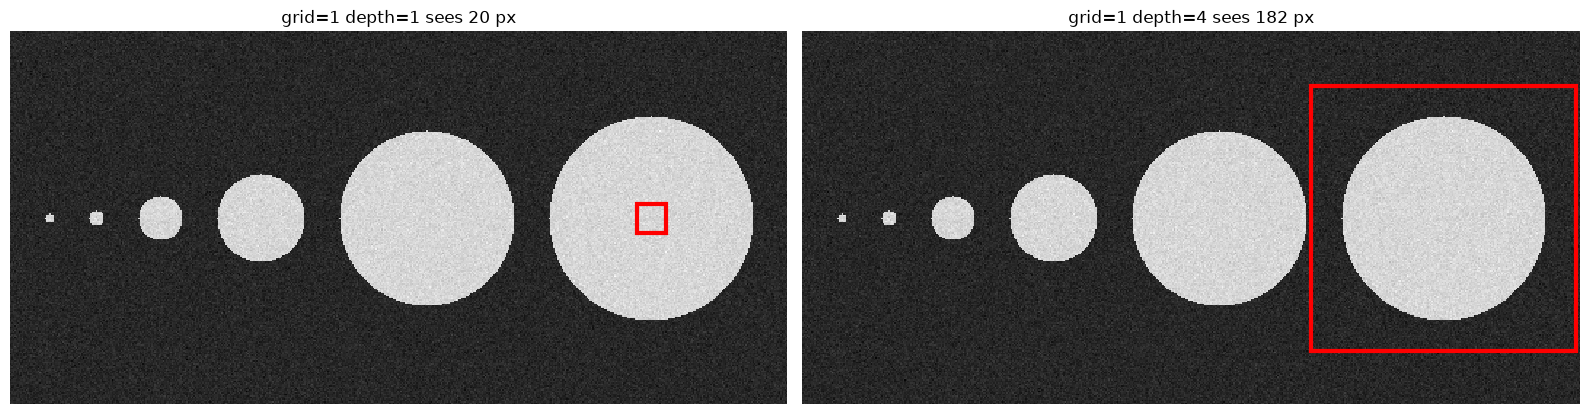

In [9]:
cy, cx = test_img.shape[0] // 2, test_img.shape[1] - 24 - RADII[-1]

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for a, field, name in [(ax[0], small_net_field, f'grid={SMALL_GRID} depth={SMALL_DEPTH}'),
                       (ax[1], big_net_field, f'grid={BIG_GRID} depth={BIG_DEPTH}')]:
    a.imshow(test_img, cmap='gray')
    a.add_patch(Rectangle((cx - field / 2, cy - field / 2), field, field,
                          fill=False, edgecolor='red', linewidth=3))
    a.set_title(f'{name} sees {field} px')
    a.axis('off')
plt.tight_layout()
plt.show()

## Training data: random circles

Radii from 1 to 85, random positions, eight images. The test radii are not
these, so nothing can be memorised.

In [10]:
WORK = Path('/tmp/i2k_circles')
(WORK / 'input').mkdir(parents=True, exist_ok=True)
(WORK / 'truth').mkdir(parents=True, exist_ok=True)

train_imgs, train_lbls = circles.random(8, size=256, min_r=1, max_r=85, seed=1)

images, truths = [], []
for i, (img, lbl) in enumerate(zip(train_imgs, train_lbls)):
    tifffile.imwrite(WORK / 'input' / f'{i:03d}.tif', img)
    tifffile.imwrite(WORK / 'truth' / f'{i:03d}.tif', lbl)
    images.append(str(WORK / 'input' / f'{i:03d}.tif'))
    truths.append(str(WORK / 'truth' / f'{i:03d}.tif'))

# Validate on the training data. val_loss then tracks training fit, which is
# what drives the learning rate schedule and picks the saved weights.
train_images = images + images
train_truths = truths + truths
VAL = len(images)

print(len(images), 'pairs,', sum(int(l.max()) for l in train_lbls), 'circles')

8 pairs, 103 circles


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19765204..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20998718..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18669912..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2056349..255.0].


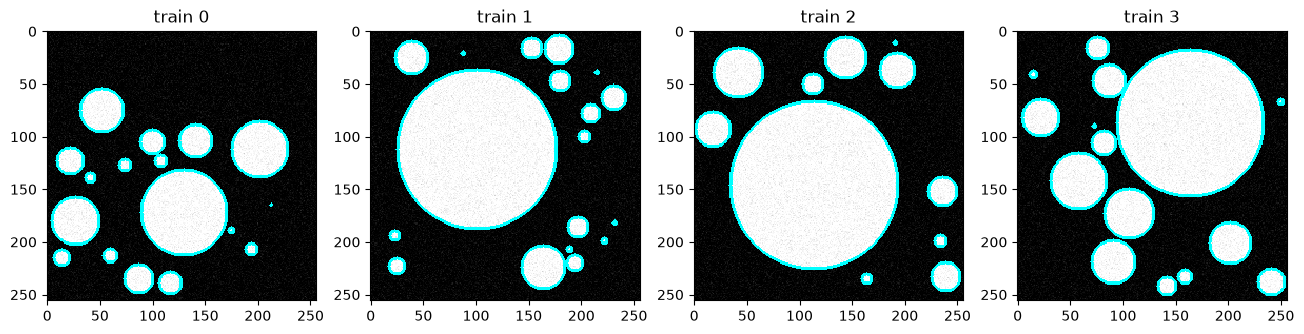

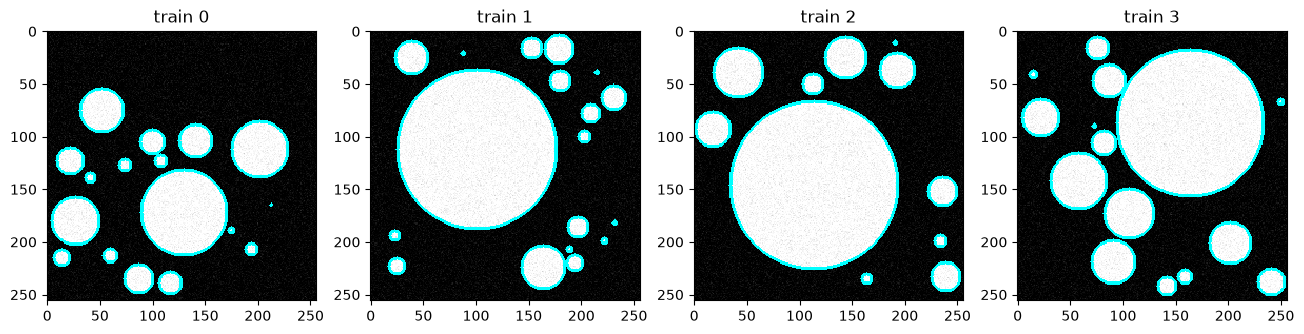

In [11]:
imshow_multi2d([mask_outline_overlay(train_imgs[i], train_lbls[i]) for i in range(4)],
               [f'train {i}' for i in range(4)], 1, 4, width=16, height=4)

## Train the small network

In [12]:
# Retire the worker: ipykernel binds a thread's output to the execution that
# created it, so a reused worker prints the first run only.
runner.close()

def show(ev):
    print(f'{ev.current}/{ev.maximum}  {ev.message}', flush=True)

small_net = runner.run(
    train_stardist2d,
    images=train_images,
    labels=train_truths,
    model_dir=str(WORK / 'models'),
    name='small_net',
    image_axes='YX',
    grid_size_xy=SMALL_GRID,
    unet_n_depth=SMALL_DEPTH,
    train_patch_size=256,
    train_batch_size=1,
    epochs=100,
    steps_per_epoch=50,
    val_size=VAL,
    on_progress=show,
)
print(small_net)

None/None  None
0/16  Reading 16 pairs
1/None  None
2/None  None
3/None  None
4/None  None
5/None  None
6/None  None
7/None  None
8/None  None
9/None  None
10/None  None
11/None  None
12/None  None
13/None  None
14/None  None
15/None  None
16/None  None
0/100  Training small_net: 8 train, 8 val, 100 epochs
1/100  Epoch 1/100 — loss 9.0824, val_loss 8.4536
2/100  Epoch 2/100 — loss 5.9343, val_loss 5.1276
3/100  Epoch 3/100 — loss 5.1075, val_loss 4.9471
4/100  Epoch 4/100 — loss 4.8548, val_loss 4.7063
5/100  Epoch 5/100 — loss 4.7131, val_loss 4.6054
6/100  Epoch 6/100 — loss 4.6690, val_loss 4.5145
7/100  Epoch 7/100 — loss 4.4639, val_loss 4.4208
8/100  Epoch 8/100 — loss 4.4115, val_loss 4.3405
9/100  Epoch 9/100 — loss 4.4550, val_loss 4.3953
10/100  Epoch 10/100 — loss 4.4349, val_loss 4.3099
11/100  Epoch 11/100 — loss 4.3682, val_loss 4.3970
12/100  Epoch 12/100 — loss 4.2683, val_loss 4.2258
13/100  Epoch 13/100 — loss 4.3436, val_loss 4.2314
14/100  Epoch 14/100 — loss 4.1899

## Train the big network

In [13]:
runner.close()

big_net = runner.run(
    train_stardist2d,
    images=train_images,
    labels=train_truths,
    model_dir=str(WORK / 'models'),
    name='big_net',
    image_axes='YX',
    grid_size_xy=BIG_GRID,
    unet_n_depth=BIG_DEPTH,
    train_patch_size=256,
    train_batch_size=1,
    epochs=100,
    steps_per_epoch=50,
    val_size=VAL,
    on_progress=show,
)
print(big_net)

None/None  None
0/16  Reading 16 pairs
1/None  None
2/None  None
3/None  None
4/None  None
5/None  None
6/None  None
7/None  None
8/None  None
9/None  None
10/None  None
11/None  None
12/None  None
13/None  None
14/None  None
15/None  None
16/None  None
0/100  Training big_net: 8 train, 8 val, 100 epochs
1/100  Epoch 1/100 — loss 8.8183, val_loss 8.7178
2/100  Epoch 2/100 — loss 5.8409, val_loss 4.2656
3/100  Epoch 3/100 — loss 3.9783, val_loss 3.4113
4/100  Epoch 4/100 — loss 3.4684, val_loss 3.2811
5/100  Epoch 5/100 — loss 3.3277, val_loss 3.0086
6/100  Epoch 6/100 — loss 3.1762, val_loss 2.9434
7/100  Epoch 7/100 — loss 2.5633, val_loss 2.4060
8/100  Epoch 8/100 — loss 2.2086, val_loss 2.1028
9/100  Epoch 9/100 — loss 1.8690, val_loss 1.4000
10/100  Epoch 10/100 — loss 1.2440, val_loss 1.1194
11/100  Epoch 11/100 — loss 1.0940, val_loss 1.4857
12/100  Epoch 12/100 — loss 1.0465, val_loss 0.9137
13/100  Epoch 13/100 — loss 0.9837, val_loss 0.9381
14/100  Epoch 14/100 — loss 1.0242, 

## Predict on the test image

Six circles, sizes it never saw, from 6 px to 140 px.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22470585..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22470585..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22470585..255.0].


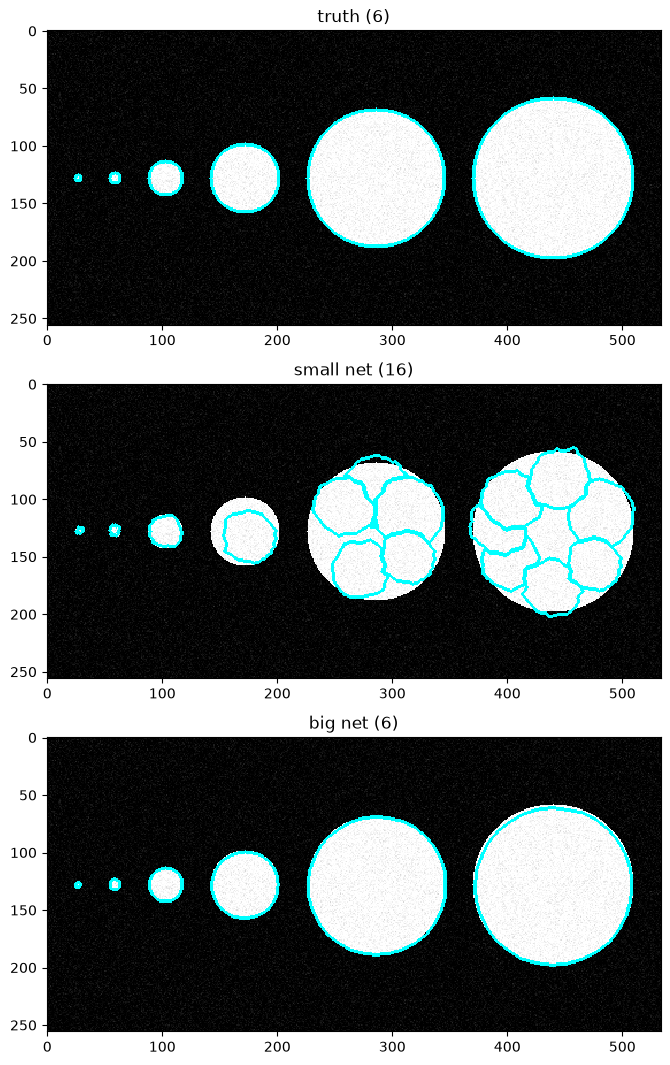

In [15]:
by_small_net = runner.run(stardist2d_custom, image=test_img,
                          model_dir=small_net, normalize=False)
by_big_net = runner.run(stardist2d_custom, image=test_img,
                        model_dir=big_net, normalize=False)

fig = imshow_multi2d(
    [mask_outline_overlay(test_img, test_lbl),
     mask_outline_overlay(test_img, by_small_net),
     mask_outline_overlay(test_img, by_big_net)],
    [f'truth ({test_lbl.max()})',
     f'small net ({by_small_net.max()})',
     f'big net ({by_big_net.max()})'],
    3, 1, width=13, height=13,
)

## Measured size against true size

This is the point. A network that cannot see the edge has to guess the size.

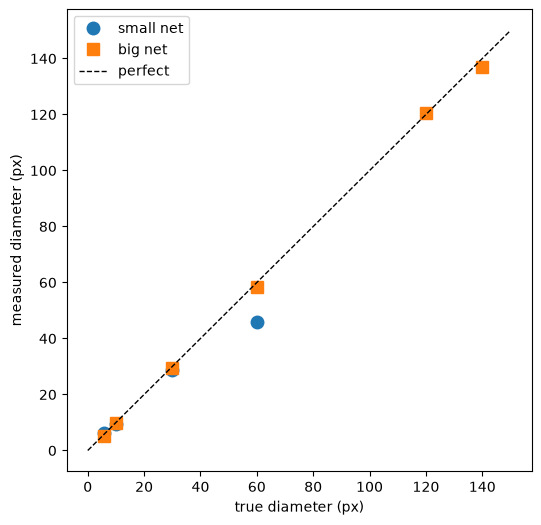

In [16]:
truth_props = {p.label: p for p in regionprops(test_lbl)}

fig, a = plt.subplots(figsize=(6, 6))
for pred, name, style in [(by_small_net, 'small net', 'o'), (by_big_net, 'big net', 's')]:
    found = {p.label: p.equivalent_diameter_area for p in regionprops(pred)}
    xs, ys = [], []
    for label, p in truth_props.items():
        y, x = (int(v) for v in p.centroid)
        hit = pred[y, x]
        if hit:
            xs.append(p.equivalent_diameter_area)
            ys.append(found[hit])
    a.plot(xs, ys, style, label=name, markersize=9)

a.plot([0, 150], [0, 150], 'k--', linewidth=1, label='perfect')
a.set_xlabel('true diameter (px)')
a.set_ylabel('measured diameter (px)')
a.legend()
plt.show()

## What to take away

Match the field to the object. A field smaller than the object cannot see the
edges, so it guesses the size instead of measuring it.